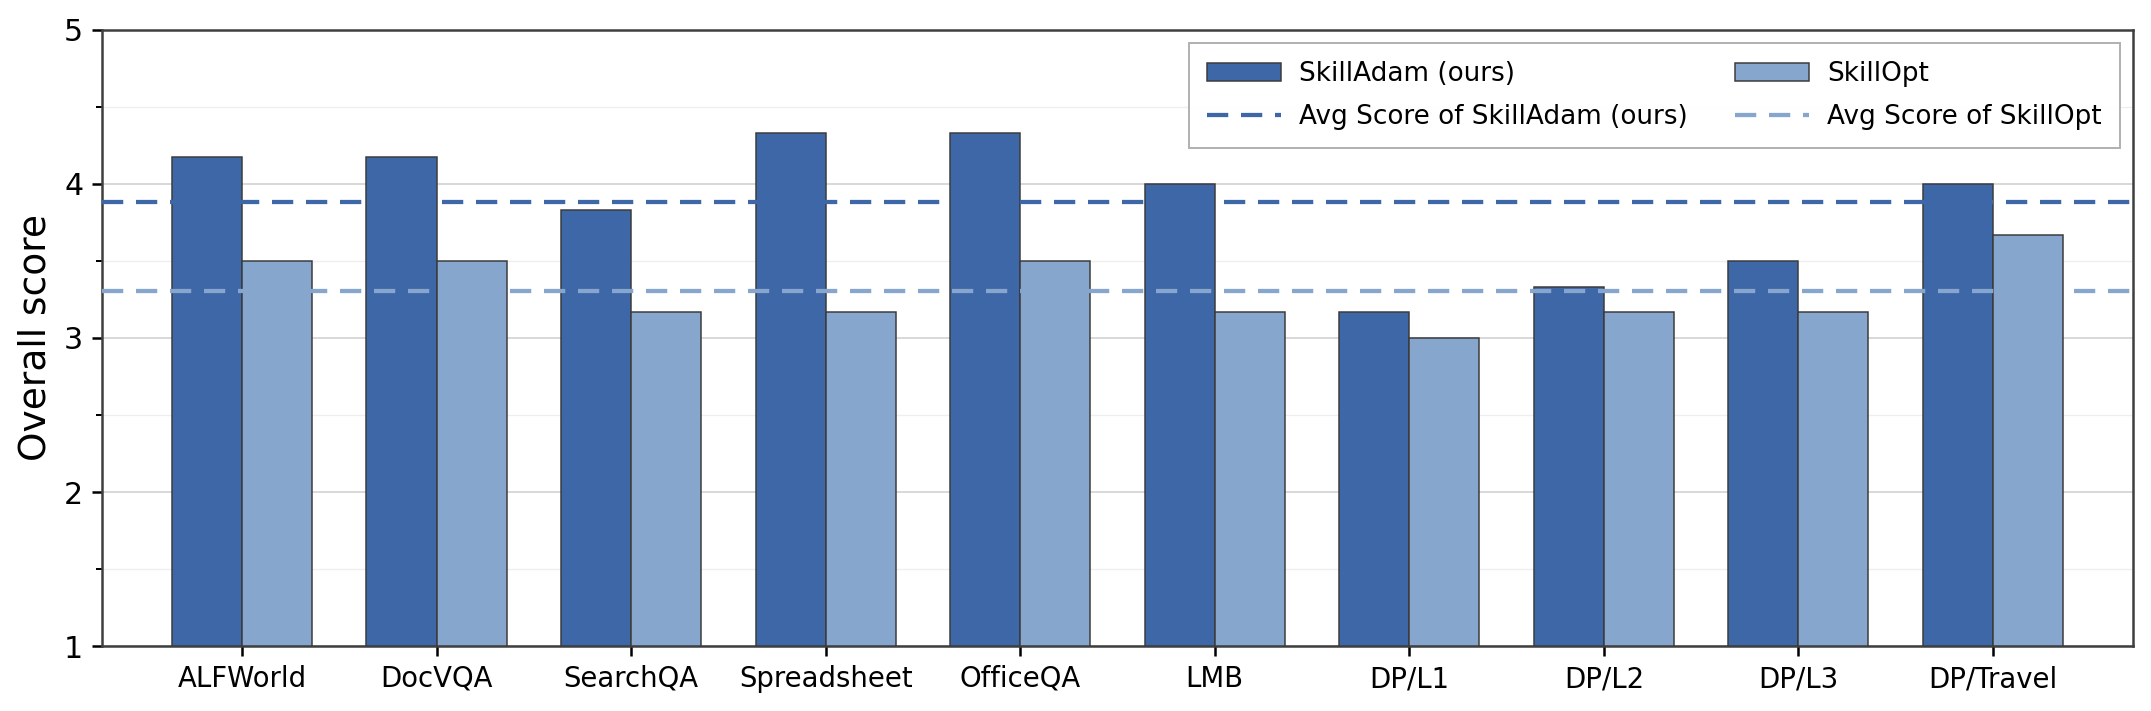

SkillAdam average: 3.88
SkillOpt average : 3.30
Saved PDF: /data00/home/fanmeihao/projects/OptiHarnessForCost/fig_judge.pdf
Saved PNG: /data00/home/fanmeihao/projects/OptiHarnessForCost/fig_judge.png


In [18]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


# ============================================================
# 1. Data
# ============================================================
BENCHMARKS = [
    "ALFWorld",
    "DocVQA",
    "SearchQA",
    "Spreadsheet",
    "OfficeQA",
    "LMB",
    "DP/L1",
    "DP/L2",
    "DP/L3",
    "DP/Travel",
]

OURS = np.array([
    4.17, 4.17, 3.83, 4.33, 4.33,
    4.00, 3.17, 3.33, 3.50, 4.00,
])

SKILLOPT = np.array([
    3.50, 3.50, 3.17, 3.17, 3.50,
    3.17, 3.00, 3.17, 3.17, 3.67,
])


# ============================================================
# 2. Publication style
# ============================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,

    "axes.labelsize": 15,
    "axes.linewidth": 1.0,

    "xtick.labelsize": 11,
    "ytick.labelsize": 12,

    "legend.fontsize": 10.5,

    # Embed editable TrueType fonts in exported PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Academic blue palette   7E03BC
COLOR_OURS = "#3E67A8"
COLOR_SKILLOPT = "#86A6CE"
EDGE_COLOR = "#3A3A3A"


# ============================================================
# 3. Geometry and statistics
# ============================================================
x = np.arange(len(BENCHMARKS), dtype=float)

# Wider bars
bar_width = 0.36

avg_ours = OURS.mean()
avg_skillopt = SKILLOPT.mean()


# ============================================================
# 4. Plot
# ============================================================
fig, ax = plt.subplots(
    figsize=(12, 4),
    dpi=180,
)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.set_axisbelow(True)


# ------------------------------------------------------------
# Grid lines: behind bars and mean lines
# ------------------------------------------------------------
ax.grid(
    axis="y",
    which="major",
    color="#D9D9D9",
    linestyle="-",
    linewidth=0.8,
    zorder=0,
)

ax.grid(
    axis="y",
    which="minor",
    color="#EEEEEE",
    linestyle="-",
    linewidth=0.5,
    zorder=0,
)


# ------------------------------------------------------------
# Bars
# zorder=3: bars are above the grid but below average lines
# ------------------------------------------------------------
bars_ours = ax.bar(
    x - bar_width / 2,
    OURS - 1.0,
    bottom=1.0,
    width=bar_width,
    color=COLOR_OURS,
    edgecolor=EDGE_COLOR,
    linewidth=0.6,
    label="SkillAdam (ours)",
    zorder=3,
)

bars_skillopt = ax.bar(
    x + bar_width / 2,
    SKILLOPT - 1.0,
    bottom=1.0,
    width=bar_width,
    color=COLOR_SKILLOPT,
    edgecolor=EDGE_COLOR,
    linewidth=0.6,
    label="SkillOpt",
    zorder=3,
)


# ------------------------------------------------------------
# Average score lines
# zorder=5: dashed lines are drawn in front of the bars
# ------------------------------------------------------------
avg_line_ours = ax.axhline(
    y=avg_ours,
    color=COLOR_OURS,
    linestyle=(0, (5, 3)),
    linewidth=1.7,
    alpha=1.0,
    label="Avg Score of SkillAdam (ours)",
    zorder=5,
)

avg_line_skillopt = ax.axhline(
    y=avg_skillopt,
    color=COLOR_SKILLOPT,
    linestyle=(0, (5, 3)),
    linewidth=1.7,
    alpha=1.0,
    label="Avg Score of SkillOpt",
    zorder=5,
)


# ============================================================
# 5. Axes
# ============================================================
ax.set_ylabel("Overall score")

ax.set_ylim(1.0, 5.0)
ax.set_yticks([1, 2, 3, 4, 5])
ax.yaxis.set_minor_locator(MultipleLocator(0.5))

# All benchmarks are equally spaced
ax.set_xticks(x)
ax.set_xticklabels(
    BENCHMARKS,
    rotation=0,
    ha="center",
)

# Symmetric horizontal margins
ax.set_xlim(
    x[0] - 0.72,
    x[-1] + 0.72,
)

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    width=1.0,
    length=4,
)

ax.tick_params(
    axis="y",
    which="minor",
    direction="out",
    width=0.8,
    length=2.5,
)


# ------------------------------------------------------------
# Closed rectangular frame
# ------------------------------------------------------------
for spine in ["left", "right", "top", "bottom"]:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color("#3F3F3F")
    ax.spines[spine].set_linewidth(1.0)


# ============================================================
# 6. Two-column legend
# ============================================================
# Matplotlib fills a multi-column legend column by column.
# This ordering produces:
#
# First row:  SkillAdam (ours)              SkillOpt
# Second row: Avg Score of SkillAdam        Avg Score of SkillOpt
#
legend_handles = [
    bars_ours,
    avg_line_ours,
    bars_skillopt,
    avg_line_skillopt,
]

legend_labels = [
    "SkillAdam (ours)",
    "Avg Score of SkillAdam (ours)",
    "SkillOpt",
    "Avg Score of SkillOpt",
]

legend = ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    ncol=2,
    loc="upper right",
    frameon=True,
    fancybox=False,
    framealpha=0.96,
    edgecolor="#AFAFAF",
    borderpad=0.7,
    labelspacing=0.65,
    columnspacing=1.8,
    handlelength=2.8,
    handletextpad=0.7,
)

legend.get_frame().set_linewidth(0.8)
legend.set_zorder(10)


# ============================================================
# 7. Layout, save, and display
# ============================================================
fig.tight_layout(pad=0.9)

output_stem = Path("fig_judge")

pdf_path = output_stem.with_suffix(".pdf")
png_path = output_stem.with_suffix(".png")

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
)

plt.show()
plt.close(fig)

print(f"SkillAdam average: {avg_ours:.2f}")
print(f"SkillOpt average : {avg_skillopt:.2f}")
print(f"Saved PDF: {pdf_path.resolve()}")
print(f"Saved PNG: {png_path.resolve()}")

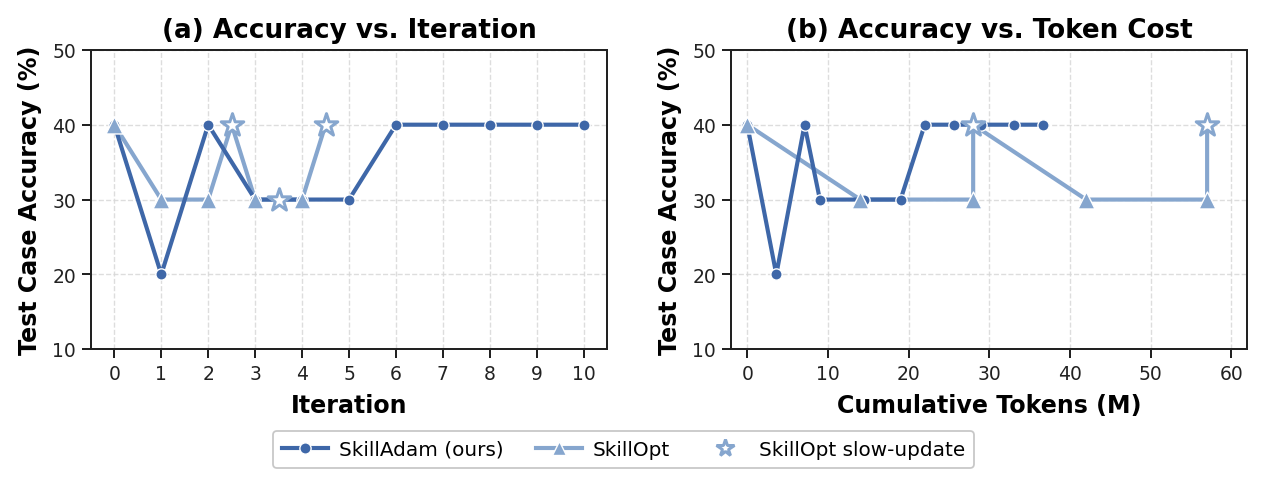

Saved PDF: fig_dynamics.pdf
Saved PNG: fig_dynamics.png


In [30]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# Data
# ============================================================
ours_iter_x = np.array(
    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    dtype=float,
)

ours_acc = np.array(
    [40, 20, 40, 30, 30, 30, 40, 40, 40, 40, 40],
    dtype=float,
)

skillopt_iter_x = np.array(
    [0, 1, 2, 2.5, 3, 3.5, 4, 4.5],
    dtype=float,
)

skillopt_iter_acc = np.array(
    [40, 30, 30, 40, 30, 30, 30, 40],
    dtype=float,
)

skillopt_regular_iter_x = np.array(
    [0, 1, 2, 3, 4],
    dtype=float,
)

skillopt_regular_iter_acc = np.array(
    [40, 30, 30, 30, 30],
    dtype=float,
)

skillopt_slow_iter_x = np.array(
    [2.5, 3.5, 4.5],
    dtype=float,
)

skillopt_slow_iter_acc = np.array(
    [40, 30, 40],
    dtype=float,
)

ours_token_x = np.array(
    [0.0, 3.6, 7.1, 9.0, 14.5, 19.0, 22.0, 25.6, 29.0, 33.0, 36.6],
    dtype=float,
)

skillopt_token_x = np.array(
    [0, 14, 28, 28, 42, 57, 57],
    dtype=float,
)

skillopt_token_acc = np.array(
    [40, 30, 30, 40, 30, 30, 40],
    dtype=float,
)

skillopt_regular_token_x = np.array(
    [0, 14, 28, 42, 57],
    dtype=float,
)

skillopt_regular_token_acc = np.array(
    [40, 30, 30, 30, 30],
    dtype=float,
)

skillopt_slow_token_x = np.array(
    [28, 57],
    dtype=float,
)

skillopt_slow_token_acc = np.array(
    [40, 40],
    dtype=float,
)


# ============================================================
# Compact publication style
# ============================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 7.5,

    "axes.titlesize": 10.5,
    "axes.titleweight": "bold",

    "axes.labelsize": 9.5,
    "axes.labelweight": "semibold",
    "axes.linewidth": 0.8,

    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,

    "legend.fontsize": 8.0,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# Colors
# ============================================================
COLOR_OURS = "#3E67A8"
COLOR_SKILLOPT = "#86A6CE"

COLOR_GRID = "#D8D8D8"
COLOR_FRAME = "#222222"


# ============================================================
# Size parameters
# ============================================================
FIGSIZE = (7.1, 2.75)

LINE_WIDTH = 1.65

OURS_MARKER_SIZE = 4.5
SKILLOPT_MARKER_AREA = 46
SLOW_MARKER_AREA = 90

MARKER_EDGE_WIDTH = 0.55
SLOW_EDGE_WIDTH = 1.2


# ============================================================
# Drawing helpers
# ============================================================
def style_axis(ax):
    ax.set_facecolor("white")
    ax.set_axisbelow(True)

    ax.grid(
        axis="both",
        which="major",
        linestyle="--",
        linewidth=0.55,
        color=COLOR_GRID,
        alpha=0.85,
        zorder=0,
    )

    for spine in ["left", "right", "top", "bottom"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(COLOR_FRAME)
        ax.spines[spine].set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        width=0.8,
        length=3.5,
        pad=2.5,
        colors="#222222",
    )


def draw_skilladam(ax, x, y):
    ax.plot(
        x,
        y,
        color=COLOR_OURS,
        linewidth=LINE_WIDTH,
        marker="o",
        markersize=OURS_MARKER_SIZE,
        markerfacecolor=COLOR_OURS,
        markeredgecolor="white",
        markeredgewidth=MARKER_EDGE_WIDTH,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=4,
    )


def draw_skillopt(
    ax,
    line_x,
    line_y,
    regular_x,
    regular_y,
    slow_x,
    slow_y,
):
    ax.plot(
        line_x,
        line_y,
        color=COLOR_SKILLOPT,
        linewidth=LINE_WIDTH,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=3,
    )

    # Regular SkillOpt points: filled triangle
    ax.scatter(
        regular_x,
        regular_y,
        marker="^",
        s=SKILLOPT_MARKER_AREA,
        facecolor=COLOR_SKILLOPT,
        edgecolor="white",
        linewidth=MARKER_EDGE_WIDTH,
        zorder=5,
    )

    # Slow-update points: hollow five-point star
    ax.scatter(
        slow_x,
        slow_y,
        marker="*",
        s=SLOW_MARKER_AREA,
        facecolor="white",
        edgecolor=COLOR_SKILLOPT,
        linewidth=SLOW_EDGE_WIDTH,
        zorder=6,
    )


# ============================================================
# Shared legend
# ============================================================
legend_handles = [
    Line2D(
        [0],
        [0],
        color=COLOR_OURS,
        linewidth=LINE_WIDTH,
        marker="o",
        markersize=OURS_MARKER_SIZE,
        markerfacecolor=COLOR_OURS,
        markeredgecolor="white",
        markeredgewidth=MARKER_EDGE_WIDTH,
        label="SkillAdam (ours)",
    ),
    Line2D(
        [0],
        [0],
        color=COLOR_SKILLOPT,
        linewidth=LINE_WIDTH,
        marker="^",
        markersize=5.3,
        markerfacecolor=COLOR_SKILLOPT,
        markeredgecolor="white",
        markeredgewidth=MARKER_EDGE_WIDTH,
        label="SkillOpt",
    ),
    Line2D(
        [0],
        [0],
        linestyle="none",
        marker="*",
        markersize=7.2,
        markerfacecolor="white",
        markeredgecolor=COLOR_SKILLOPT,
        markeredgewidth=SLOW_EDGE_WIDTH,
        label="SkillOpt slow-update",
    ),
]


# ============================================================
# Plot
# ============================================================
fig, (ax_iter, ax_token) = plt.subplots(
    1,
    2,
    figsize=FIGSIZE,
    dpi=180,
)

fig.patch.set_facecolor("white")


# ------------------------------------------------------------
# (a) Accuracy vs. Iteration
# ------------------------------------------------------------
style_axis(ax_iter)

draw_skilladam(
    ax_iter,
    ours_iter_x,
    ours_acc,
)

draw_skillopt(
    ax=ax_iter,
    line_x=skillopt_iter_x,
    line_y=skillopt_iter_acc,
    regular_x=skillopt_regular_iter_x,
    regular_y=skillopt_regular_iter_acc,
    slow_x=skillopt_slow_iter_x,
    slow_y=skillopt_slow_iter_acc,
)

ax_iter.set_title(
    "(a) Accuracy vs. Iteration",
    pad=5,
)

ax_iter.set_xlabel(
    "Iteration",
    labelpad=4,
)

ax_iter.set_ylabel(
    "Test Case Accuracy (%)",
    labelpad=4,
)

ax_iter.set_xlim(-0.5, 10.5)
ax_iter.set_ylim(10, 50)

ax_iter.set_xticks(np.arange(0, 11, 1))
ax_iter.set_yticks([10, 20, 30, 40, 50])


# ------------------------------------------------------------
# (b) Accuracy vs. Token Cost
# ------------------------------------------------------------
style_axis(ax_token)

draw_skilladam(
    ax_token,
    ours_token_x,
    ours_acc,
)

draw_skillopt(
    ax=ax_token,
    line_x=skillopt_token_x,
    line_y=skillopt_token_acc,
    regular_x=skillopt_regular_token_x,
    regular_y=skillopt_regular_token_acc,
    slow_x=skillopt_slow_token_x,
    slow_y=skillopt_slow_token_acc,
)

ax_token.set_title(
    "(b) Accuracy vs. Token Cost",
    pad=5,
)

ax_token.set_xlabel(
    "Cumulative Tokens (M)",
    labelpad=4,
)

ax_token.set_ylabel(
    "Test Case Accuracy (%)",
    labelpad=4,
)

ax_token.set_xlim(-2, 62)
ax_token.set_ylim(10, 50)

ax_token.set_xticks([0, 10, 20, 30, 40, 50, 60])
ax_token.set_yticks([10, 20, 30, 40, 50])


# ============================================================
# Shared legend
# ============================================================
legend = fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.005),
    ncol=3,
    frameon=True,
    fancybox=True,
    framealpha=0.97,
    edgecolor="#C5C5C5",
    columnspacing=1.6,
    handlelength=2.3,
    handletextpad=0.55,
    borderpad=0.45,
    labelspacing=0.4,
)

legend.get_frame().set_linewidth(0.7)


# ============================================================
# Layout and export
# ============================================================
fig.subplots_adjust(
    left=0.083,
    right=0.988,
    bottom=0.255,
    top=0.86,
    wspace=0.24,
)

output_stem = Path("fig_dynamics")

fig.savefig(
    output_stem.with_suffix(".pdf"),
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
)

fig.savefig(
    output_stem.with_suffix(".png"),
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
)

plt.show()
plt.close(fig)

print(f"Saved PDF: {output_stem.with_suffix('.pdf')}")
print(f"Saved PNG: {output_stem.with_suffix('.png')}")

In [2]:
print("Please solve this issue: \n# Cost-saving instructions\n## Batching\n- Combine independent operations (search + read, multiple searches) in one step.\n- Batch multiple independent tool calls (e.g. read-lines + bash, list-files + bash) into one step when they have no dependency on each other.\n- Read a wider range of lines instead of multiple partial reads of the same file.\n- After edits, use diff output instead of re-reading changed files.\n- Create files directly instead of through shell heredocs to avoid escaping and reduce output size.\n## When to give up / pivot\n- If a command fails once (import error, bad path, build fail), pivot immediately.\n- If run-tests times out, fall back to bash with explicit timeout and output filtering; do not retry the evolved tool.\n- After targeted edits, skip verification searches \u2014 validate the fix directly instead.\n- Skip git history exploration \u2014 read current source files directly instead.\n## When to exit early / skip validation\n- If the environment is broken, submit the best-effort fix without running tests.\n- If tests fail from unrelated issues, submit without retrying.\n- Validate targeted fixes with direct python -c execution instead of re-running test suites.\n- Do not build/package/install to test; use the test runner directly.\n## Risky moves\n- When build is broken, validate via source-level execution and git diff; if targeted tests have import errors but the fix is correct, submit anyway.\n## Observation size\n- Read files by line range or tail instead of dumping the entire file.\n- Use filtered search with result limits instead of full recursive grep.\n- Request only filenames when line-level detail is not needed.\n- Use the test runner's tail/grep options to reduce output size.\n- Only examine files directly relevant to the task.\n\n\n## Native-tool failure fallback\n- Evolved tools have a hard execution deadline. If one times out, runs out of memory, or returns a non-zero result, avoid repeating the same call unchanged.\n- Recommended response: narrow the evolved-tool path/query or otherwise reduce its scope; alternatively, fall back to an equivalent bash command.\n\n\n\n---\n\nInheritDocstrings metaclass doesn't work for properties\nInside the InheritDocstrings metaclass it uses `inspect.isfunction` which returns `False` for properties.\n\n\nYou can execute bash commands and edit files to implement the necessary changes.\n\n## Recommended Workflow\n\nThis workflow should be done step-by-step so that you can iterate on your changes and any possible problems.\n\n1. Analyze the codebase by finding and reading relevant files\n2. Create a script to reproduce the issue\n3. Edit the source code to resolve the issue\n4. Verify your fix works by running your script again\n5. Test edge cases to ensure your fix is robust\n6. Submit your changes and finish your work by issuing the following command: `echo COMPLETE_TASK_AND_SUBMIT_FINAL_OUTPUT`.\n   Do not combine it with any other command. <important>After this command, you cannot continue working on this task.</important>\n\n## Command Execution Rules\n\nYou are operating in an environment where\n\n1. You issue at least one command\n2. The system executes the command(s) in a subshell\n3. You see the result(s)\n4. You write your next command(s)\n\nEach response should include:\n\n1. **Reasoning text** where you explain your analysis and plan\n2. At least one tool call with your command\n\n**CRITICAL REQUIREMENTS:**\n\n- Your response SHOULD include reasoning text explaining what you're doing\n- Your response MUST include AT LEAST ONE bash tool call\n- Directory or environment variable changes are not persistent. Every action is executed in a new subshell.\n- However, you can prefix any action with `MY_ENV_VAR=MY_VALUE cd /path/to/working/dir && ...` or write/load environment variables from files\n- Submit your changes and finish your work by issuing the following command: `echo COMPLETE_TASK_AND_SUBMIT_FINAL_OUTPUT`.\n  Do not combine it with any other command. <important>After this command, you cannot continue working on this task.</important>\n\nExample of a CORRECT response:\n<example_response>\nI need to understand the structure of the repository first. Let me check what files are in the current directory to get a better understanding of the codebase.\n\n[Makes bash tool call with {\"command\": \"ls -la\"} as arguments]\n</example_response>\n\n<system_information>\nLinux 5.4.143.bsk.8-amd64 #5.4.143.bsk.8 SMP Debian 5.4.143.bsk.8 Wed Jul 20 08:43:36 UTC  x86_64\n</system_information>\n\n## Useful command examples\n\n### Create a new file:\n\n```bash\ncat <<'EOF' > newfile.py\nimport numpy as np\nhello = \"world\"\nprint(hello)\nEOF\n```\n\n### Edit files with sed:```bash\n# Replace all occurrences\nsed -i 's/old_string/new_string/g' filename.py\n\n# Replace only first occurrence\nsed -i 's/old_string/new_string/' filename.py\n\n# Replace first occurrence on line 1\nsed -i '1s/old_string/new_string/' filename.py\n\n# Replace all occurrences in lines 1-10\nsed -i '1,10s/old_string/new_string/g' filename.py\n```\n\n### View file content:\n\n```bash\n# View specific lines with numbers\nnl -ba filename.py | sed -n '10,20p'\n```\n\n### Any other command you want to run\n\n```bash\nanything\n```")

Please solve this issue: 
# Cost-saving instructions
## Batching
- Combine independent operations (search + read, multiple searches) in one step.
- Batch multiple independent tool calls (e.g. read-lines + bash, list-files + bash) into one step when they have no dependency on each other.
- Read a wider range of lines instead of multiple partial reads of the same file.
- After edits, use diff output instead of re-reading changed files.
- Create files directly instead of through shell heredocs to avoid escaping and reduce output size.
## When to give up / pivot
- If a command fails once (import error, bad path, build fail), pivot immediately.
- If run-tests times out, fall back to bash with explicit timeout and output filtering; do not retry the evolved tool.
- After targeted edits, skip verification searches — validate the fix directly instead.
- Skip git history exploration — read current source files directly instead.
## When to exit early / skip validation
- If the environment is brok